In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


orders = pd.read_csv("olist_orders_dataset.csv")

item = pd.read_csv("olist_order_items_dataset.csv")

pruduct = pd.read_csv("olist_products_dataset.csv")

customer = pd.read_csv("olist_customers_dataset.csv")

payment = pd.read_csv("olist_order_payments_dataset.csv")

categori = pd.read_csv("product_category_name_translation.csv")







In [46]:
pruduct['product_category_name'] = pruduct['product_category_name'].fillna('Other')

In [47]:
all_data = {
    "Ordess":orders,
    "Customer":customer,
    "Payments":payment,
    "İtem":item,
    "Pruducts":pruduct
   
}

for name, table in all_data.items():
   print(f"\n--- {name} Tablosu Analizi ---")
   print(f"Shape: {table.shape}")
   null_count = table.isnull().sum().sum()
   print(null_count)
   display(table.head(3))
print("-" * 30)



--- Ordess Tablosu Analizi ---
Shape: (99441, 8)
4908


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00



--- Customer Tablosu Analizi ---
Shape: (99441, 5)
0


,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP



--- Payments Tablosu Analizi ---
Shape: (103886, 5)
0


...


--- İtem Tablosu Analizi ---
Shape: (112650, 7)
0


,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.9,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.9,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.0,17.87



--- Pruducts Tablosu Analizi ---
Shape: (32951, 9)
1838


,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0


------------------------------


In [48]:
df = (
    orders
    .merge(customer,on="customer_id",how="left")
    .merge(item,on="order_id",how="left")
    .merge(pruduct,on="product_id",how="left")
    .merge(payment,on="order_id",how="left")
    
)
print(f"Yeni satır/sütun sayısı: {df.shape}")
display(df.head())

Yeni satır/sütun sayısı: (118434, 30)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,...,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,payment_sequential,payment_type,payment_installments,payment_value
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,...,268.0,4.0,500.0,19.0,8.0,13.0,1.0,credit_card,1.0,18.12
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,...,268.0,4.0,500.0,19.0,8.0,13.0,3.0,voucher,1.0,2.00
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,...,268.0,4.0,500.0,19.0,8.0,13.0,2.0,voucher,1.0,18.59
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,af07308b275d755c9edb36a90c618231,47813,...,178.0,1.0,400.0,19.0,13.0,19.0,1.0,boleto,1.0,141.46
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,3a653a41f6f9fc3d2a113cf8398680e8,75265,...,232.0,1.0,420.0,24.0,19.0,21.0,1.0,credit_card,3.0,179.12


In [49]:
df = df.merge(
    categori,
    on="product_category_name",
    how="left"
)

In [50]:
#Veri setinde bazı kolonlarda eksik değerler tespit edildi.
#Özellikle teslimat tarihine ait kolonlarda eksiklik olduğu görüldü.
#Ancak inceleme sonucunda bu eksikliklerin büyük kısmının shipped, canceled, unavailable gibi sipariş durumlarından kaynaklandığı belirlendi.
# Bu nedenle eksik değerler veri hatası olarak değerlendirilmedi.
df[df["order_delivered_customer_date"].isnull()]["order_status"].value_counts()

order_status
shipped        1245
canceled        738
unavailable     650
processing      375
invoiced        373
delivered         8
created           5
approved          3
Name: count, dtype: int64

In [51]:
#Birleştirme sonrası tekrar eden kayıt bulunmadı.
df.duplicated().sum()

np.int64(0)

In [52]:
toplam_satis = df["payment_value"].sum() # Sadece bir değişkene ata
print(f"Toplam Satış: {toplam_satis}") # Ekrana yazdır

Toplam Satış: 20470726.659999996


In [53]:
#Ortalama sipariş tutarı yaklaşık 205,86 olarak hesaplanmıştır.
# Bu sonuç müşterilerin tek siparişte ortalama 206 birimlik harcama yaptığını göstermektedir.

df["ortalama"] = df["payment_value"].sum() / df["order_id"].nunique()


In [54]:
#Satışların büyük kısmının belirli büyük şehirlerde yoğunlaştığı görülmektedir.Özellikle São Paulo açık ara lider konumdadır.
#Bu durum nüfus yoğunluğu, ekonomik aktivite ve müşteri yoğunluğu ile açıklanabilir.
# Bölgesel pazarlama ve müşteri kazanımı çalışmalarında yüksek performans gösteren şehirler önceliklendirilebilir.
df.groupby("customer_city")["payment_value"].sum().sort_values(ascending=False).head(5)

customer_city
sao paulo         2872846.47
rio de janeiro    1574144.72
belo horizonte     506192.87
brasilia           432388.25
curitiba           331851.61
Name: payment_value, dtype: float64

In [55]:
#Kategori bazlı gelir analizinde ev yaşamı, sağlık ve teknoloji odaklı kategorilerin öne çıktığı görülmektedir.
# Özellikle bed_bath_table kategorisi en yüksek toplam geliri üretmiştir 
# Bunun yanında health_beauty ve computers_accessories kategorileri de güçlü performans göstermektedir.Şirket ürün stratejisini yüksek gelir üreten kategorilere odaklayabilir.
df.groupby("product_category_name_english")["payment_value"].sum().sort_values(ascending=False).head(10)

product_category_name_english
bed_bath_table           1712553.67
health_beauty            1657373.12
computers_accessories    1585330.45
furniture_decor          1430176.39
watches_gifts            1429216.68
sports_leisure           1392127.56
housewares               1094758.13
auto                      852294.33
garden_tools              838280.75
cool_stuff                779698.00
Name: payment_value, dtype: float64

In [56]:
#En çok  satılan getiren katagoriler
#Kategori bazlı analizinde ev yaşamı, sağlık ve teknoloji odaklı kategorilerin öne çıktığı görülmektedir.
# Özellikle bed_bath_table kategorisi en yüksek satışı üretmiştir.
# Bunun yanında health_beauty ve computers_accessories kategorileri de güçlü performans göstermektedir.
# Şirket ürün stratejisini yüksek gelir üreten kategorilere odaklayabilir.
df.groupby("product_category_name_english")["order_id"].count().sort_values(ascending=False).head(10)


product_category_name_english
bed_bath_table           11823
health_beauty             9975
sports_leisure            8945
furniture_decor           8744
computers_accessories     8082
housewares                7355
watches_gifts             6201
telephony                 4721
garden_tools              4574
auto                      4379
Name: order_id, dtype: int64

In [57]:
#Ortalama müşteri harcama degeri
df.groupby("customer_unique_id")["payment_value"].sum().mean()

np.float64(213.02371232933734)

In [58]:
#En çok gelir getiren ödeme yöntemi
#Ödeme yöntemi analizinde kredi kartının açık ara en yüksek geliri ürettiği görülmüştür.
# Toplam satışların büyük kısmı kredi kartı ile gerçekleşmiştir.
# Boleto ikinci sırada yer alsa da kredi kartı ile arasında belirgin fark bulunmaktadır.Bu durum müşterilerin yüksek tutarlı alışverişlerde kredi kartını tercih ettiğini göstermektedir.
df.groupby("payment_type")["payment_value"].sum().sort_values(ascending=False)

payment_type
credit_card    15694885.84
boleto          4086820.71
voucher          432602.19
debit_card       256417.92
not_defined           0.00
Name: payment_value, dtype: float64

In [59]:
#Taksite göre gelir incelemesi
#Taksit sayısı arttıkça ortalama ödeme tutarının genel olarak yükseldiği görülmektedir.Düşük taksitlerde daha düşük sepet oluşurken,
# yüksek taksit seçeneklerinde ortalama sipariş değeri artmaktadır.Bu durum müşterilerin yüksek fiyatlı ürünlerde taksit imkanını kullandığını göstermektedir.
df.groupby("payment_installments")["payment_value"].mean().sort_values(ascending=False)

payment_installments
24.0    801.737941
20.0    568.072857
18.0    493.345263
10.0    432.709368
15.0    423.653804
16.0    395.081429
12.0    324.413515
8.0     310.709620
21.0    267.428000
23.0    236.480000
6.0     234.633566
22.0    228.710000
9.0     208.015333
5.0     197.775330
7.0     194.091517
4.0     179.195178
17.0    174.602500
14.0    166.521250
3.0     153.785922
13.0    148.677222
2.0     134.628332
1.0     132.527551
11.0    123.983462
0.0     106.190000
Name: payment_value, dtype: float64

In [60]:
#Teslimatlar ortalama kaç gün geçikiyor
#Teslimat gecikme analizi gerçekleştirildi.Sonuçlara göre siparişler ortalama 12 gün erken teslim edilmektedir
# Medyan değerin de yaklaşık -13 olması erken teslimat davranışının genel bir eğilim olduğunu göstermektedir.
# Ancak bazı siparişlerde ciddi gecikmeler olduğu görülmektedir.En yüksek gecikme 188 gün olarak hesaplanmıştır.Bu durum operasyonel istisnalar veya veri kalitesi açısından ayrıca incelenebilir.
df["order_delivered_customer_date"] = pd.to_datetime(df["order_delivered_customer_date"])
df["order_estimated_delivery_date"] = pd.to_datetime(df["order_estimated_delivery_date"])
df["delay_days"] = (df["order_delivered_customer_date"] - df["order_estimated_delivery_date"]).dt.days
df["delay_days"].describe()


count    115037.000000
mean        -12.042073
std          10.165136
min        -147.000000
25%         -17.000000
50%         -13.000000
75%          -7.000000
max         188.000000
Name: delay_days, dtype: float64

In [61]:
#Hangi şehir daha geç alıyor siparişleri
df.groupby("customer_city")["delay_days"].mean().sort_values(ascending=False).head(10)

customer_city
novo brasil           126.0
capinzal do norte      78.0
adhemar de barros      73.0
arace                  53.0
serra dos dourados     52.0
marcelino vieira       49.0
aramari                43.0
humildes               42.0
rubineia               41.0
quintana               38.6
Name: delay_days, dtype: float64

In [62]:
#Şehir bazında teslimat performansı analiz edilmiştir.
# Analiz sonucunda yüksek sipariş hacmine sahip şehirlerde teslimatların genel olarak tahmini teslim tarihinden daha erken gerçekleştiği görülmüştür.
# İncelenen şehirlerin tamamında ortalama gecikme değerinin negatif olması, lojistik operasyonlarının beklenen teslim süresinden daha hızlı tamamlandığını göstermektedir.
#Sonuç olarak veri setinde yaygın bir teslimat gecikmesi problemi gözlenmemiştir.
city_delay = df.groupby("customer_city")["delay_days"].agg(["mean", "count"])
result = city_delay[city_delay["count"] > 50].sort_values("mean", ascending=False).head(10)
print(result)

                        mean  count
customer_city                      
sao goncalo        -6.374165    449
nova friburgo      -6.490798    163
maceio             -6.561538    260
camacari           -7.373333     75
sao vicente        -7.492063    189
rio das ostras     -7.539474    152
sao joao de meriti -7.826347    167
itaperuna          -7.851852     54
hortolandia        -7.912500    160
volta redonda      -8.099237    262


In [63]:
#Ödeme yöntemlerine göre ortalama sipariş tutarı incelendiğinde kredi kartının en yüksek ortalama harcamaya sahip olduğu görülmüştür.
#Teslim süreleri ise tüm ödeme yöntemlerinde birbirine yakın olup ödeme yönteminin teslim süresine belirgin bir etkisi olmadığı gözlemlenmiştir.
df.groupby(
"payment_type"
).agg(
{
"payment_value":"mean",
"delay_days":"mean"
}
)

,payment_value,delay_days
payment_type,,
boleto,177.402470,-11.293131
credit_card,179.809887,-12.242862
debit_card,151.011731,-11.468240
not_defined,0.000000,NaN
voucher,67.520242,-12.171811


In [64]:
#Hangi kategori daha geç geliyor
#Analiz sonuçlarına göre, incelenen tüm ürün kategorilerinde ortalama `delay_days` değerinin negatif çıkması, 
# ürünlerin tahmin edilen teslimat tarihinden daha erken müşteriye ulaştığını göstermektedir. 
#Bu durum, lojistik süreçlerin planlanandan daha verimli işlediğini ve genel teslimat performansının oldukça yüksek olduğunu ortaya koymaktadır.
df.groupby("product_category_name_english")["delay_days"].mean().sort_values(ascending=False).head(10)

product_category_name_english
arts_and_craftmanship                -6.791667
furniture_mattress_and_upholstery    -7.175000
home_comfort_2                       -8.483871
home_confort                         -9.744681
food                                 -9.953398
audio                               -10.232804
fashion_underwear_beach             -10.707143
books_imported                      -11.050847
electronics                         -11.147845
construction_tools_lights           -11.177419
Name: delay_days, dtype: float64

In [65]:
#Ürünün geç gelip gelmemesine bakıyoruz
df["delivery_type"] = np.where(df["delay_days"] > 0,"geç","erken")
df.groupby("delivery_type")["payment_value"].mean()

delivery_type
erken    172.240621
geç      181.819158
Name: payment_value, dtype: float64

In [66]:
#müşteri kitlesinin büyük çoğunluğunun 'low' ve 'medium' segmentlerinde yoğunlaştığı görülmektedir. 'Vip' segmentindeki müşteri sayısının diğerlerine oranla çok daha az olması, 
#yüksek tutarlı harcama yapan kullanıcıların özel bir grup oluşturduğunu ve pazarlama stratejilerinde bu kitleye yönelik farklı bir yaklaşım geliştirilebileceğini göstermektedir."
df["customer_segment"] = pd.cut(df["payment_value"],bins=[0,100,300,1000,100000],labels=["low","medium","high","vip"])
df["customer_segment"].value_counts()

customer_segment
low       54865
medium    49125
high      12651
vip        1781
Name: count, dtype: int64

In [67]:
#Her şehirdeki en pahılı 3 ürün
df["en_pahili"] = df.groupby("customer_city")["payment_value"].rank(ascending=False)
df[df["en_pahili"] <= 3].head(10)

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,...,payment_sequential,payment_type,payment_installments,payment_value,product_category_name_english,ortalama,delay_days,delivery_type,customer_segment,en_pahili
7,a4591c265e18cb1dcee52889e2d8acc3,503740e9ca751ccdda7ba28e9ab8f608,delivered,2017-07-09 21:57:05,2017-07-09 22:10:13,2017-07-11 14:58:04,2017-07-26 10:57:55,2017-08-01,80bb27c7c16e8f973207a5086ab329e2,86320,...,1.0,credit_card,6.0,175.26,auto,205.858013,-6.0,erken,medium,1.0
10,76c6e866289321a7c93b82b54852dc33,f54a9f0e6b351c431402b8461ea51999,delivered,2017-01-23 18:29:09,2017-01-25 02:50:47,2017-01-26 14:16:31,2017-02-02 14:08:10,2017-03-06,39382392765b6dc74812866ee5ee92a7,99655,...,1.0,boleto,1.0,35.95,furniture_decor,205.858013,-32.0,erken,low,1.0
38,1790eea0b567cf50911c057cf20f90f9,52142aa69d8d0e1247ab0cada0f76023,delivered,2018-04-16 21:15:39,2018-04-16 22:10:26,2018-04-18 13:05:09,2018-05-05 12:28:34,2018-05-15,a6fefcd9f434474cf6fcd8ed1102fd63,55540,...,1.0,credit_card,4.0,224.90,air_conditioning,205.858013,-10.0,erken,medium,2.0
43,60550084e6b4c0cb89a87df1f3e5ebd9,f5458ddc3545711efa883dd7ae7c4497,delivered,2018-02-21 18:15:12,2018-02-23 02:10:52,2018-02-27 18:52:09,2018-03-13 23:58:43,2018-03-29,661a5e18a28b34880ccc60112f2b8e8e,62360,...,1.0,boleto,1.0,66.79,electronics,205.858013,-16.0,erken,low,3.0
75,f271576bed568e896f99eb710cd3a6f8,5dda11942d4f77bee3a46d71e442aec4,delivered,2018-01-07 21:44:54,2018-01-07 21:51:28,2018-01-10 21:56:09,2018-01-17 20:26:31,2018-02-14,6a0e43f0d7e1b5539e4c58a26ebe35da,46740,...,1.0,credit_card,4.0,824.76,construction_tools_construction,205.858013,-28.0,erken,high,1.5
76,f271576bed568e896f99eb710cd3a6f8,5dda11942d4f77bee3a46d71e442aec4,delivered,2018-01-07 21:44:54,2018-01-07 21:51:28,2018-01-10 21:56:09,2018-01-17 20:26:31,2018-02-14,6a0e43f0d7e1b5539e4c58a26ebe35da,46740,...,1.0,credit_card,4.0,824.76,construction_tools_construction,205.858013,-28.0,erken,high,1.5
96,634e8f4c0f6744a626f77f39770ac6aa,05e996469a2bf9559c7122b87e156724,delivered,2017-08-09 18:32:47,2017-08-09 18:45:18,2017-08-10 20:21:53,2017-08-16 18:17:54,2017-08-31,5229b8e4d7d2b9b676c2083c17b1ecd0,93180,...,2.0,voucher,1.0,227.20,watches_gifts,205.858013,-15.0,erken,medium,1.0
105,e4de6d53ecff736bc68804b0b6e9f635,9f6618c17568ac301465fe7ad056c674,delivered,2017-10-16 14:56:50,2017-10-17 03:49:34,2017-10-27 22:14:21,2017-11-08 21:25:24,2017-11-21,e3bcfea9bab07b492391664fc1ffc28a,44180,...,1.0,boleto,1.0,231.12,office_furniture,205.858013,-13.0,erken,medium,1.0
106,6b860b35691d486e45dc98e3514ec5f6,fee181bf648906d1c57f84f216976286,delivered,2017-12-08 09:42:43,2017-12-09 02:49:54,2017-12-11 15:19:04,2017-12-19 18:43:35,2018-01-03,4754e3b66497719a91b36268ed9c5718,13760,...,1.0,boleto,1.0,574.36,sports_leisure,205.858013,-15.0,erken,high,2.0
107,ec341c54a5ebf8ee0a67a8632aa7579b,df9b032b2ad0fd6bf37dfb48e5f83845,delivered,2017-08-26 16:53:30,2017-08-27 17:04:12,2017-08-30 13:26:32,2017-09-08 20:39:56,2017-09-21,410979f3cfd34e467d4fad78bd0f0219,89440,...,1.0,credit_card,2.0,29.92,bed_bath_table,205.858013,-13.0,erken,low,3.0


In [68]:
#Tekrar alışveriş yapam müşteri oranı yüzde kaç
#Müşteri tabanımızın %3.12'si birden fazla sipariş vererek tekrar eden müşteri profili oluşturmaktadır. Bu oran, müşteri sadakatinin henüz 
#geliştirilmeye açık olduğunu ve mevcut müşterileri elde tutma (retention) stratejilerine odaklanmamız gerektiğini göstermektedir.
(df.groupby("customer_unique_id")["order_id"].nunique() > 1).mean()*100

np.float64(3.1187562437562435)

In [69]:
#Tekara alışveriş yapan müşteriler daha çok mu harcama yapıyor
customer_orders = (df.groupby("customer_unique_id")["order_id"].nunique())
df["tekrar_müsteriler"] = (df["customer_unique_id"].map(customer_orders)> 1).apply(lambda x:'tekrar eden' if x > 1 else 'tek seferlik')
df.groupby("tekrar_müsteriler")["payment_value"].mean()

tekrar_müsteriler
tek seferlik    172.849395
Name: payment_value, dtype: float64

In [70]:
#Pahalı ürün daha uzun teslim mi bekliyor
#Müşterilerimizin harcama tutarlarından bağımsız olarak, lojistik operasyonlarımız genelinde yüksek bir verimlilik gözlemlenmektedir.
#Tüm segmentlerde ürünler beklenen tarihten ortalama 11-12 gün önce teslim edilmektedir. Harcama miktarı ile teslimat süresi arasında doğrusal veya güçlü bir ilişki bulunmamaktadır; 
#bu da lojistik süreçlerimizin tüm müşteri grupları için standart ve başarılı bir seviyede işlediğini göstermektedir.
labels = ["Çok Düşük", "Düşük", "Orta", "Yüksek", "Çok Yüksek"]
df.groupby(pd.qcut(df["payment_value"],5,labels=labels),observed=False)["delay_days"].mean()

payment_value
Çok Düşük    -11.535416
Düşük        -11.674112
Orta         -12.027130
Yüksek       -12.349128
Çok Yüksek   -12.633524
Name: delay_days, dtype: float64

In [71]:
#Müşteriler hafta sonu mu daha çok alışveriş yapıyor yoksa hafta sonu mu
#Müşterilerimizin harcama alışkanlıkları hafta içi ve hafta sonu bazında incelendiğinde, hafta içi yapılan alışverişlerde sepet ortalamasının (174.91) hafta sonuna göre (165.79) daha yüksek olduğu görülmektedir.
#Bu bulgu, alışverişin hafta içi, muhtemelen mesai saatleri içerisinde veya planlı ihtiyaçlar dahilinde gerçekleştiğine işaret etmektedir.
#Hafta sonu harcamalarındaki bu küçük düşüş, tüketicilerin hafta sonunda daha çok 'göz atma' veya 'düşük tutarlı keyfi harcamalar' yapma eğiliminde olabileceğini düşündürmektedir
df["order_purchase_timestamp"] = pd.to_datetime(df["order_purchase_timestamp"])
df["weekend"] = (df["order_purchase_timestamp"].dt.weekday>= 5)
df["weekend"] = df["weekend"].map({True: "Hafta Sonu", False: "Hafta İçi"})
df.groupby("weekend")["payment_value"].mean()

weekend
Hafta Sonu    165.797079
Hafta İçi     174.914525
Name: payment_value, dtype: float64

In [72]:
#Teslimat süresi artıkça harcama düşüyor mu
#Yapılan korelasyon analizi sonucunda, teslimat gecikme süresi ile müşteri harcama tutarı arasında anlamlı bir ilişki bulunmamıştır (-0.019).
#Bu bulgu, lojistik süreçlerimizin harcama segmentlerinden bağımsız olarak standart bir şekilde yürütüldüğünü ve yüksek tutarlı alışverişlerin lojistik önceliklendirme üzerinde bir etkisi olmadığını göstermektedir.
df[["delay_days","payment_value"]].corr()

,delay_days,payment_value
delay_days,1.000000,-0.019554
payment_value,-0.019554,1.000000


In [73]:
df["order_purchase_timestamp"] = pd.to_datetime(df["order_purchase_timestamp"])
df["year"] = df["order_purchase_timestamp"].dt.year
df["month"] = df["order_purchase_timestamp"].dt.month
df["month_name"] = df["order_purchase_timestamp"].dt.month_name()

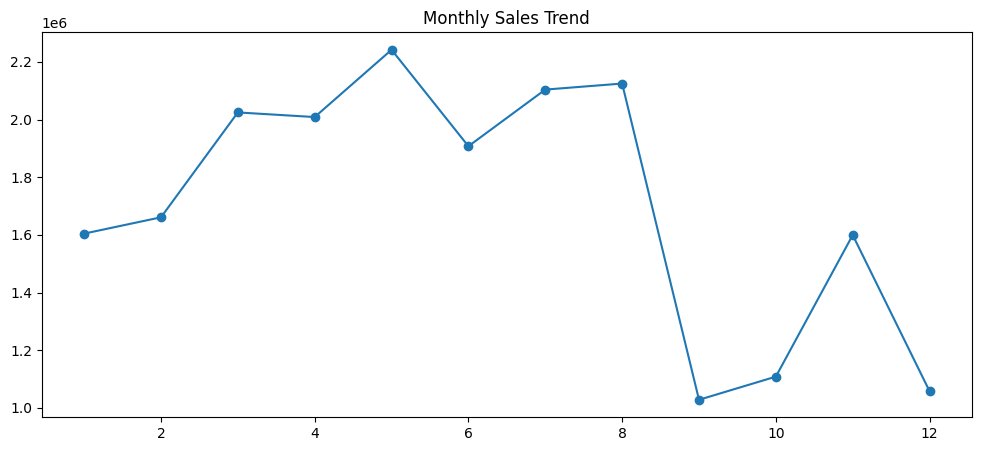

In [74]:
# Satışlar aylara göre nasıl değişiyor
# Analiz sonuçlarına göre, aylık satış performansında belirgin dalgalanmalar gözlenmektedir.
# Mayıs ayı (5. ay), toplamda 2.242.130,09 birimlik satış hacmi ile yılın zirvesini temsil etmektedir. Buna karşın, 9. ve 12. aylar yıllık bazda en düşük satış hacimlerine sahip olup, bu dön
# kampanya eksikliği vb.) incelenmesi, sonraki dönemlerdeki ciro optimizasyonu için kritik öneme sahiptir.

df["aylik_satiş"] = df.groupby("month")["payment_value"].sum().sort_index()

df["aylik_satiş"].plot(figsize=(12,5), marker="o")
plt.title("Monthly Sales Trend")
plt.show()

In [75]:
df["aylik_büyüme_orani"] = df["aylik_satiş"].pct_change(fill_method=None)*100
df["aylik_büyüme_orani"]

0               NaN
1               NaN
2          3.527780
3         21.904231
4         -0.792590
            ...    
118429          NaN
118430          NaN
118431          NaN
118432          NaN
118433          NaN
Name: aylik_büyüme_orani, Length: 118434, dtype: float64

In [76]:
df[df["month"] == 9]["product_category_name"].value_counts()


product_category_name
cama_mesa_banho                      567
esporte_lazer                        473
beleza_saude                         399
moveis_decoracao                     364
brinquedos                           313
                                    ... 
construcao_ferramentas_iluminacao      1
moveis_colchao_e_estofado              1
seguros_e_servicos                     1
fashion_roupa_infanto_juvenil          1
cine_foto                              1
Name: count, Length: 66, dtype: int64

In [77]:
# 9. ayda kategori bazlı toplam ciro (payment_value)
#Eğer 9. ayda toplam satışlar düştüyse, suçlusu muhtemelen telefonia_fixa kategorisindeki bir sıkıntıdır.
#Çünkü bu kategori cironun büyük kısmını oluşturuyor. Eğer burada bir stok sorunu veya fiyat rekabeti kaybı yaşandıysa, toplam cironun %51 düşmesine şaşmamak lazım.
dokuzuncu_ay = df[df["month"] == 9]
ciro_analizi = dokuzuncu_ay.groupby("product_category_name")["payment_value"].sum().sort_values(ascending=False)
print(ciro_analizi.head(10))

product_category_name
telefonia_fixa            109638.75
cama_mesa_banho            83521.19
esporte_lazer              74154.52
beleza_saude               67818.62
informatica_acessorios     61235.29
relogios_presentes         58348.81
pcs                        56402.28
moveis_decoracao           53899.31
cool_stuff                 45818.79
brinquedos                 42094.60
Name: payment_value, dtype: float64


In [78]:
#Ham verideki sert dalgalanmaları '3 Aylık Hareketli Ortalama' ile filtreledim. Bu analiz, yılın ikinci yarısında satışlarda sistematik bir düşüş trendi olduğunu kanıtladı.
#Bu sayede, tekil aylık düşüşlere değil, uzun vadeli ivme kaybına odaklanarak pazarlama ve stok stratejilerimizi optimize etmemiz gerektiğini tespit ettim
rolling_sales = df["aylik_satiş"].rolling(3).mean()

rolling_sales

0                NaN
1                NaN
2                NaN
3         1763370.19
4         1898160.62
             ...    
118429           NaN
118430           NaN
118431           NaN
118432           NaN
118433           NaN
Name: aylik_satiş, Length: 118434, dtype: float64

In [79]:
#Siparişlerin %97.13’ü başarılı bir şekilde teslim edilmiştir.
#İptal (%0.62) ve stok bulunamaması (%0.54) oranları %1’in altında kalarak operasyonel süreçlerin hata payının minimize edildiğini göstermektedir.
#Lojistik altyapı yüksek verimlilikle çalışmakta olup, müşteri memnuniyeti ve teslimat kalitesi bakımından güvenilir bir performans sergilemektedir.
(
df["order_status"]
.value_counts(normalize=True)
*100
)

order_status
delivered      97.132580
shipped         1.051218
canceled        0.629042
unavailable     0.548829
processing      0.316632
invoiced        0.314943
created         0.004222
approved        0.002533
Name: proportion, dtype: float64

In [80]:
#Kategori başına ortalama harcama
(
df.groupby("product_category_name_english")
["payment_value"]
.mean()
.sort_values(ascending=False)
)

product_category_name_english
computers                                1268.734318
fixed_telephony                           763.875498
small_appliances_home_oven_and_coffee     656.786154
agro_industry_and_commerce                471.153214
home_appliances_2                         464.789030
                                            ...     
fashion_underwear_beach                    88.295417
food                                       88.267433
cds_dvds_musicals                          85.673571
flowers                                    67.060909
home_comfort_2                             55.178710
Name: payment_value, Length: 71, dtype: float64

In [81]:
#Şirket cirosunun büyük bir kısmı hafta içi günlerde gerçekleşmekte olup, Pazartesi ve Salı günleri haftalık performansın zirvesini oluşturmaktadır.
#Hafta sonu günlerinde (Cumartesi-Pazar) ciro bazlı bir düşüş gözlemlenmektedir.
#Bu veriler, pazarlama kampanyalarının hafta sonu trafiğini canlandırmaya odaklanması gerektiğini veya lojistik/operasyonel hazırlıkların hafta başındaki yoğunluğa göre planlanması gerektiğini ortaya koymaktadır.
(
df.groupby(
df["order_purchase_timestamp"].dt.day_name()
)
["payment_value"]
.sum()
)

order_purchase_timestamp
Friday       3035921.47
Monday       3335776.83
Saturday     2162443.23
Sunday       2285063.41
Thursday     3127936.94
Tuesday      3340461.15
Wednesday    3183123.63
Name: payment_value, dtype: float64

In [82]:
#Müşteri hareketliliği sabah 10:00 itibarıyla keskin bir şekilde artıyor ve gün boyu 10:00 ile 22:00 arasında yüksek seyrediyor. Özellikle 13:00, 16:00 ve 21:00 saatleri günün en yoğun zamanları.
#Bu veriler, pazarlama bildirimlerinin (push notification) veya kampanya duyurularının müşteri yoğunluğunun zirvede olduğu 13:00 - 21:00 saat aralığında yapılmasının, dönüşüm oranlarını doğrudan artıracağını göstermektedir.
#Ayrıca web sitesi bakım çalışmalarının,trafiğin en düşük olduğu gece saatlerine planlanması operasyonel riski minimize edecektir.
df["hour"]=(
df["order_purchase_timestamp"]
.dt.hour
)

(
df.groupby("hour")
["order_id"]
.nunique()
)

hour
0     2394
1     1170
2      510
3      272
4      206
5      188
6      502
7     1231
8     2967
9     4785
10    6177
11    6578
12    5995
13    6518
14    6569
15    6454
16    6675
17    6150
18    5769
19    5982
20    6193
21    6217
22    5816
23    4123
Name: order_id, dtype: int64

In [83]:
df.to_csv('olist_temizlenmis.csv', index=False)

In [84]:
# Doğru yöntem: Değişkene ata ve print ile yazdır
toplam_satis = df["payment_value"].sum()
toplam_siparis = df["order_id"].nunique()

print(f"Toplam Satış: {toplam_satis:,.2f}")
print(f"Toplam Sipariş Sayısı: {toplam_siparis}")

Toplam Satış: 20,470,726.66
Toplam Sipariş Sayısı: 99441
